In [1]:
import warnings
warnings.filterwarnings('ignore')

from sigpyproc.readers import FilReader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import dates
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator
from datetime import datetime, timedelta
import astropy.units as u
from astropy.time import Time
from astropy.visualization import ImageNormalize, PercentileInterval

plt.rcParams['figure.dpi'] = 100 #sets default resolution for displayed figures (pixel density)
plt.rcParams['savefig.dpi'] = 300 #sets default res for saved figs - note it's higher
plt.rcParams['figure.facecolor'] = 'white' #sets default background colour of displayed figures to white
plt.rcParams['savefig.facecolor'] = 'white' # ,, saved figs ,,

print(plt.get_backend())
path = '/home/mnedal/data/I-LOFAR'

module://matplotlib_inline.backend_inline


In [2]:
stokes = 'I'
filename = f'{path}/realta_ilofar_stokes{stokes}_20240514T1635.fil'

In [3]:
a = FilReader(filename) # header
header = a.header.to_dict() #file headers are put in a dictionary

In [5]:
header

{'filename': '/home/mnedal/data/I-LOFAR/realta_ilofar_stokesI_20240514T1635.fil',
 'data_type': 'filterbank',
 'nchans': 488,
 'foff': -0.1953125,
 'fch1': 200.0,
 'nbits': 32,
 'tsamp': 0.00131072,
 'tstart': 60444.690972213044,
 'nsamples': 3433227,
 'nifs': 1,
 'coord': <SkyCoord (ICRS): (ra, dec) in deg
     (0., 0.)>,
 'azimuth': <Angle 235.90465428 deg>,
 'zenith': <Angle 133.53284027 deg>,
 'telescope': 'MeerKAT',
 'backend': 'FAKE',
 'source': 'Sun357',
 'frame': 'topocentric',
 'ibeam': 0,
 'nbeams': 0,
 'dm': 0,
 'period': 0,
 'accel': 0,
 'signed': False,
 'rawdatafile': 'unknown',
 'stream_info': {'entries': [{'filename': '/home/mnedal/data/I-LOFAR/realta_ilofar_stokesI_20240514T1635.fil',
    'hdrlen': 347,
    'datalen': 6701659104,
    'nsamples': 3433227,
    'tstart': 60444.690972213044,
    'tsamp': 0.00131072}]},
 'basename': 'realta_ilofar_stokesI_20240514T1635',
 'extension': '.fil',
 'telescope_id': 64,
 'machine_id': 0,
 'bandwidth': 95.3125,
 'ftop': 200.0976562

In [ ]:
# filename = f'{path}/Sun357_20240514_stokesI.fil'
# a = FilReader(filename) # header
# header = a.header.to_dict()
# header

In [6]:
tstart_obs_str = Time(a.header.tstart, format='mjd').iso #tstart header tells the start time - needs to be converted to this format
n_samples = a.header.nsamples
print(tstart_obs_str, n_samples, sep='\n')

2024-05-14 16:34:59.999
3433227


In [7]:
data = a.read_block(start=0, nsamps=n_samples)

In [8]:
print(data.shape)

(488, 3433227)


In [9]:
# making time axis
tstart = Time(data.header.tstart, format='mjd')                    # tstart.iso will tell the time in format yyyy-mm-dd hh:mm:ss
tarray = tstart + (np.arange(data.shape[1])*data.header.tsamp*u.s) # making the time array for realta time resolution
print(len(tarray), tarray[0].iso, tarray[-1].iso, sep='\n')

3433227
2024-05-14 16:34:59.999
2024-05-14 17:49:59.997


In [10]:
dt = datetime.strptime(tarray[1].iso, '%Y-%m-%d %H:%M:%S.%f') - datetime.strptime(tarray[0].iso, '%Y-%m-%d %H:%M:%S.%f') #finds dt between 1st and 2nd timestamps
print('Time cadence:', dt.total_seconds()*1000, 'ms.')

Time cadence: 2.0 ms.


In [11]:
tarray

<Time object: scale='utc' format='mjd' value=[60444.69097221 60444.69097223 60444.69097224 ... 60444.74305549
 60444.74305551 60444.74305552]>

In [12]:
# Converting the array to datetime object
Tarray = [datetime.strptime(t.iso, '%Y-%m-%d %H:%M:%S.%f') for t in tarray]
print(Tarray[0], Tarray[-1], sep='\n')

2024-05-14 16:34:59.999000
2024-05-14 17:49:59.997000


In [13]:
Tarray

[datetime.datetime(2024, 5, 14, 16, 34, 59, 999000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 1000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 2000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 3000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 4000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 6000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 7000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 8000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 10000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 11000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 12000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 14000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 15000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 16000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 18000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 19000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 20000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 21000),
 datetime.datetime(2024, 5, 14, 16, 35, 0, 23000),
 datetime.datetime(2024, 5, 14, 16, 

In [14]:
# export the frequency axis
freqs = data.header.chan_freqs
print(freqs[0], freqs[-1], sep='\n')

200.0
104.8828125


In [15]:
def freq_axis(freqs):
    """
    Introduce gaps in the frequency axis of I-LOFAR REALTA data.
    """
    gap1 = np.flipud(freqs[288]+(np.arange(59)*0.390625)) #gap1 is an array of 143.75 + 58, 57, ..., 0 times 0.390625
    gap2 = np.flipud(freqs[88]+(np.arange(57)*0.390625)) #0.390625 ~ the ratio of the freqs range to the actual frequency range in MHz
    ax_shape = 59+57-1
    new_freq = np.zeros(ax_shape+freqs.shape[0])
    
    new_freq[0:88] = freqs[0:88] #200 - 182 (not MHz)
    new_freq[88:145]  = gap2[:57] #gap2
    new_freq[145:345] = freqs[88:288] #182 - 143
    new_freq[345:404] = gap1[:59] #gap1
    new_freq[404:] = freqs[289:] #143 - 104
    
    return new_freq

In [16]:
new_freq = freq_axis(freqs)

data = np.log10(data)
data[np.where(np.isinf(data)==True)] = 0.0

data2 = np.empty((new_freq.shape[0], data.shape[1]))    
data2[:] = np.NaN
data2[0:88] = data[0:88]
data2[145:345] = data[88:288]
data2[404:] = data[289:]

In [17]:
freq_mode3 = np.linspace(10, 90, 199)
freq_mode5 = np.linspace(110, 190, 200)
freq_mode7 = np.linspace(210, 270, 88)

df_mode3 = pd.DataFrame(data=data2[404:].T, columns=freq_mode3[::-1])
df_mode5 = pd.DataFrame(data=data2[145:345].T, columns=freq_mode5[::-1])
df_mode7 = pd.DataFrame(data=data2[:88].T, columns=freq_mode7[::-1])

In [18]:
print(df_mode3.shape, df_mode5.shape, df_mode7.shape, sep='\n')

(3433227, 199)
(3433227, 200)
(3433227, 88)


In [19]:
# Ensure the 'time' column is in datetime format
df_mode3.index = pd.to_datetime(Tarray)
df_mode5.index = pd.to_datetime(Tarray)
df_mode7.index = pd.to_datetime(Tarray)

In [ ]:
# Save the dataframes as a pickle files
df_mode3.to_pickle(f'./df_mode3_realta_stokes{stokes}.pkl')
df_mode5.to_pickle(f'./df_mode5_realta_stokes{stokes}.pkl')
df_mode7.to_pickle(f'./df_mode7_realta_stokes{stokes}.pkl')

---

## Load the dataframes from the pickle files

In [ ]:
stokes = 'I'

df_mode3 = pd.read_pickle(f'./df_mode3_realta_stokes{stokes}.pkl')
df_mode5 = pd.read_pickle(f'./df_mode5_realta_stokes{stokes}.pkl')
df_mode7 = pd.read_pickle(f'./df_mode7_realta_stokes{stokes}.pkl')

In [23]:
time_mode3 = df_mode3.index
time_mode5 = df_mode5.index
time_mode7 = df_mode7.index

freq_mode3 = df_mode3.columns
freq_mode5 = df_mode5.columns
freq_mode7 = df_mode7.columns

In [24]:
df_mode3.head()

,90.000000,89.595960,89.191919,88.787879,88.383838,87.979798,87.575758,87.171717,86.767677,86.363636,...,13.636364,13.232323,12.828283,12.424242,12.020202,11.616162,11.212121,10.808081,10.404040,10.000000
2024-05-14 16:34:59.999,1.799772,1.792704,1.819402,1.801856,1.821898,1.805349,1.839700,1.880792,1.826038,1.846514,...,3.568820,5.713190,3.028499,4.234807,3.177210,3.395557,4.988539,2.805119,5.987510,4.049678
2024-05-14 16:35:00.001,1.798050,1.805530,1.841611,1.807242,1.801061,1.821736,1.827367,1.827421,1.821073,1.861757,...,3.599643,5.800901,2.970011,4.192112,3.187352,3.541002,5.046845,2.820904,5.931093,3.924436
2024-05-14 16:35:00.002,1.802809,1.778404,1.805065,1.813894,1.830493,1.813557,1.822570,1.843120,1.855594,1.867607,...,3.567282,5.775797,2.957429,4.217224,3.177248,3.390445,5.051265,2.815365,5.915247,3.795859
2024-05-14 16:35:00.003,1.796909,1.776495,1.787806,1.820709,1.827081,1.844028,1.833397,1.855872,1.843667,1.859612,...,3.615343,5.741851,3.075492,4.240929,3.199538,3.522466,5.091839,2.799621,5.820334,3.902297
2024-05-14 16:35:00.004,1.828032,1.798176,1.811086,1.803947,1.828609,1.791825,1.842622,1.849136,1.815879,1.884669,...,3.612194,5.771443,3.025137,4.232731,3.159316,3.392504,5.093588,2.789549,5.879279,3.775813


In [21]:
# remove the const background
mode3_new = df_mode3.values - np.tile(np.nanmean(df_mode3.values,0), (df_mode3.values.shape[0],1))
mode5_new = df_mode5.values - np.tile(np.nanmean(df_mode5.values,0), (df_mode5.values.shape[0],1))
mode7_new = df_mode7.values - np.tile(np.nanmean(df_mode7.values,0), (df_mode7.values.shape[0],1))

In [25]:
df_mode3_new = pd.DataFrame(data=mode3_new, columns=freq_mode3)
df_mode5_new = pd.DataFrame(data=mode5_new, columns=freq_mode5)
df_mode7_new = pd.DataFrame(data=mode7_new, columns=freq_mode7)

df_mode3_new.index = pd.to_datetime(time_mode3)
df_mode5_new.index = pd.to_datetime(time_mode5)
df_mode7_new.index = pd.to_datetime(time_mode7)

In [26]:
df_mode3_new.head()

,90.000000,89.595960,89.191919,88.787879,88.383838,87.979798,87.575758,87.171717,86.767677,86.363636,...,13.636364,13.232323,12.828283,12.424242,12.020202,11.616162,11.212121,10.808081,10.404040,10.000000
2024-05-14 16:34:59.999,-0.097223,-0.095804,-0.072854,-0.097929,-0.081905,-0.107719,-0.083374,-0.052462,-0.119020,-0.112578,...,-0.553649,0.457031,-0.085887,0.181764,0.007515,-0.710664,0.285406,-0.121056,1.157139,0.665124
2024-05-14 16:35:00.001,-0.098944,-0.082978,-0.050645,-0.092543,-0.102741,-0.091332,-0.095708,-0.105833,-0.123986,-0.097336,...,-0.522826,0.544743,-0.144375,0.139068,0.017657,-0.565219,0.343712,-0.105271,1.100722,0.539883
2024-05-14 16:35:00.002,-0.094185,-0.110103,-0.087191,-0.085891,-0.073310,-0.099511,-0.100505,-0.090134,-0.089465,-0.091485,...,-0.555188,0.519639,-0.156957,0.164180,0.007553,-0.715776,0.348132,-0.110810,1.084876,0.411305
2024-05-14 16:35:00.003,-0.100085,-0.112013,-0.104450,-0.079076,-0.076721,-0.069039,-0.089678,-0.077382,-0.101391,-0.099480,...,-0.507127,0.485693,-0.038894,0.187885,0.029843,-0.583755,0.388706,-0.126554,0.989963,0.517743
2024-05-14 16:35:00.004,-0.068962,-0.090332,-0.081170,-0.095837,-0.075194,-0.121243,-0.080453,-0.084118,-0.129179,-0.074423,...,-0.510276,0.515284,-0.089249,0.179687,-0.010379,-0.713717,0.390455,-0.136626,1.048908,0.391259


In [27]:
# Slice the DataFrame between start_date and end_date
start_date = '2024-05-14 16:34:59.999'
# end_date   = '2024-05-14 17:00:00'

# df_mode3_slice = df_mode3.loc[start_date:end_date]
# df_mode5_slice = df_mode5.loc[start_date:end_date]
# df_mode7_slice = df_mode7.loc[start_date:end_date]

df_mode3_new = df_mode3_new.loc[start_date:]
df_mode5_new = df_mode5_new.loc[start_date:]
df_mode7_new = df_mode7_new.loc[start_date:]

In [28]:
del mode3_new
del mode5_new
del mode7_new

del df_mode3
del df_mode5
del df_mode7

In [ ]:
min_range = -0.5
max_range = 2
#allmodes = np.concatenate((df_mode3_new.values.T, df_mode5_new.values.T, df_mode7_new.values.T))
#min_range = np.percentile(allmodes, 10)
#max_range = np.percentile(allmodes, 97)

fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)
ax.pcolormesh(df_mode3_new.index, df_mode3_new.columns, df_mode3_new.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(df_mode5_new.index, df_mode5_new.columns, df_mode5_new.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(df_mode7_new.index, df_mode7_new.columns, df_mode7_new.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

# Define the custom ticks
custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks])
ax.xaxis.set_minor_locator(AutoMinorLocator(n=5))
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_ylim(ax.get_ylim()[::-1])
plt.show()

In [ ]:
typeII_1_mode3 = df_mode3_new.loc['2024-05-14 17:30:40':'2024-05-14 17:34:30']
typeII_1_mode5 = df_mode5_new.loc['2024-05-14 17:30:40':'2024-05-14 17:34:30']
typeII_1_mode7 = df_mode7_new.loc['2024-05-14 17:30:40':'2024-05-14 17:34:30']

In [ ]:
typeII_2_mode3 = df_mode3_new.loc['2024-05-14 17:35:13':'2024-05-14 17:37:00']
typeII_2_mode5 = df_mode5_new.loc['2024-05-14 17:35:13':'2024-05-14 17:37:00']
typeII_2_mode7 = df_mode7_new.loc['2024-05-14 17:35:13':'2024-05-14 17:37:00']

In [31]:
typeII_3_mode3 = df_mode3_new.loc['2024-05-14 17:36:14':'2024-05-14 17:38:40']
typeII_3_mode5 = df_mode5_new.loc['2024-05-14 17:36:14':'2024-05-14 17:38:40']
typeII_3_mode7 = df_mode7_new.loc['2024-05-14 17:36:14':'2024-05-14 17:38:40']

In [29]:
typeII_4_mode3 = df_mode3_new.loc['2024-05-14 17:40:00':'2024-05-14 17:48:00']
typeII_4_mode5 = df_mode5_new.loc['2024-05-14 17:40:00':'2024-05-14 17:48:00']
typeII_4_mode7 = df_mode7_new.loc['2024-05-14 17:40:00':'2024-05-14 17:48:00']

In [ ]:
# typeII_4_mode3 = df_mode3_new.loc['2024-05-14 17:17:00':'2024-05-14 17:30:00']
# typeII_4_mode5 = df_mode5_new.loc['2024-05-14 17:17:00':'2024-05-14 17:30:00']
# typeII_4_mode7 = df_mode7_new.loc['2024-05-14 17:17:00':'2024-05-14 17:30:00']

In [ ]:
# typeII_5_mode3 = df_mode3_new.loc['2024-05-14 17:10:00':'2024-05-14 17:17:00']
# typeII_5_mode5 = df_mode5_new.loc['2024-05-14 17:10:00':'2024-05-14 17:17:00']
# typeII_5_mode7 = df_mode7_new.loc['2024-05-14 17:10:00':'2024-05-14 17:17:00']

In [ ]:
# typeII_6_mode3 = df_mode3_new.loc['2024-05-14 17:01:52':'2024-05-14 17:04:50']
# typeII_6_mode5 = df_mode5_new.loc['2024-05-14 17:01:52':'2024-05-14 17:04:50']
# typeII_6_mode7 = df_mode7_new.loc['2024-05-14 17:01:52':'2024-05-14 17:04:50']

In [ ]:
CME_2_mode3 = df_mode3_new.loc['2024-05-14 17:30:20':'2024-05-14 17:48:00']
CME_2_mode5 = df_mode5_new.loc['2024-05-14 17:30:20':'2024-05-14 17:48:00']
CME_2_mode7 = df_mode7_new.loc['2024-05-14 17:30:20':'2024-05-14 17:48:00']

In [ ]:
herring_mode3 = df_mode3_new.loc['2024-05-14 17:30:40':'2024-05-14 17:33:40']
herring_mode5 = df_mode5_new.loc['2024-05-14 17:30:40':'2024-05-14 17:33:40']
herring_mode7 = df_mode7_new.loc['2024-05-14 17:30:40':'2024-05-14 17:33:40']

In [ ]:
del df_mode3_new
del df_mode5_new
del df_mode7_new

In [ ]:
min_range = -0.5
max_range = 2.5

fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)
ax.pcolormesh(herring_mode3.index, herring_mode3.columns, herring_mode3.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(herring_mode5.index, herring_mode5.columns, herring_mode5.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(herring_mode7.index, herring_mode7.columns, herring_mode7.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

# Define the custom ticks
custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks], fontsize = 17)
# ax.xaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlabel('Time (UT)', fontsize = 17)
ax.set_ylabel('Frequency (MHz)', fontsize = 17)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.tick_params(axis='x', labelsize=17)
#ax.set_ylim(190, 35)
ax.set_ylim(190, 110)

#ax.set_ylim(max(ax.get_ylim()[::-1]), 35) original
plt.savefig(f"herring_1730.png")
#plt.show()

In [ ]:
min_range = -0.5
max_range = 2.8

fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)
ax.pcolormesh(typeII_1_mode3.index, typeII_1_mode3.columns, typeII_1_mode3.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_1_mode5.index, typeII_1_mode5.columns, typeII_1_mode5.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_1_mode7.index, typeII_1_mode7.columns, typeII_1_mode7.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

# Define the custom ticks
custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 140, 160, 180]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks], fontsize = 17)
# ax.xaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlabel('Time (UT)', fontsize = 17)
ax.set_ylabel('Frequency (MHz)', fontsize = 17)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.tick_params(axis='x', labelsize=17)
ax.set_ylim(190, 35)
#ax.set_ylim(190, 110)

#ax.set_ylim(max(ax.get_ylim()[::-1]), 35) original
#plt.savefig(f"typeII_1730.png")
plt.show()

In [ ]:
min_range = -0.5
max_range = 2.98

fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)
ax.pcolormesh(typeII_2_mode3.index, typeII_2_mode3.columns, typeII_2_mode3.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_2_mode5.index, typeII_2_mode5.columns, typeII_2_mode5.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_2_mode7.index, typeII_2_mode7.columns, typeII_2_mode7.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

# Define the custom ticks
custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 140, 160, 180]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks], fontsize = 17)
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlabel('Time (UT)', fontsize = 17)
ax.set_ylabel('Frequency (MHz)', fontsize = 17)
ax.xaxis_date()

ax.xaxis.set_major_locator(mdates.SecondLocator(interval=30))
# Define minor ticks every 2 minutes
#ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

ax.tick_params(axis='x', labelsize=17)
ax.set_ylim(180, 49)
#plt.show()
plt.savefig(f"typeII_1735.png")

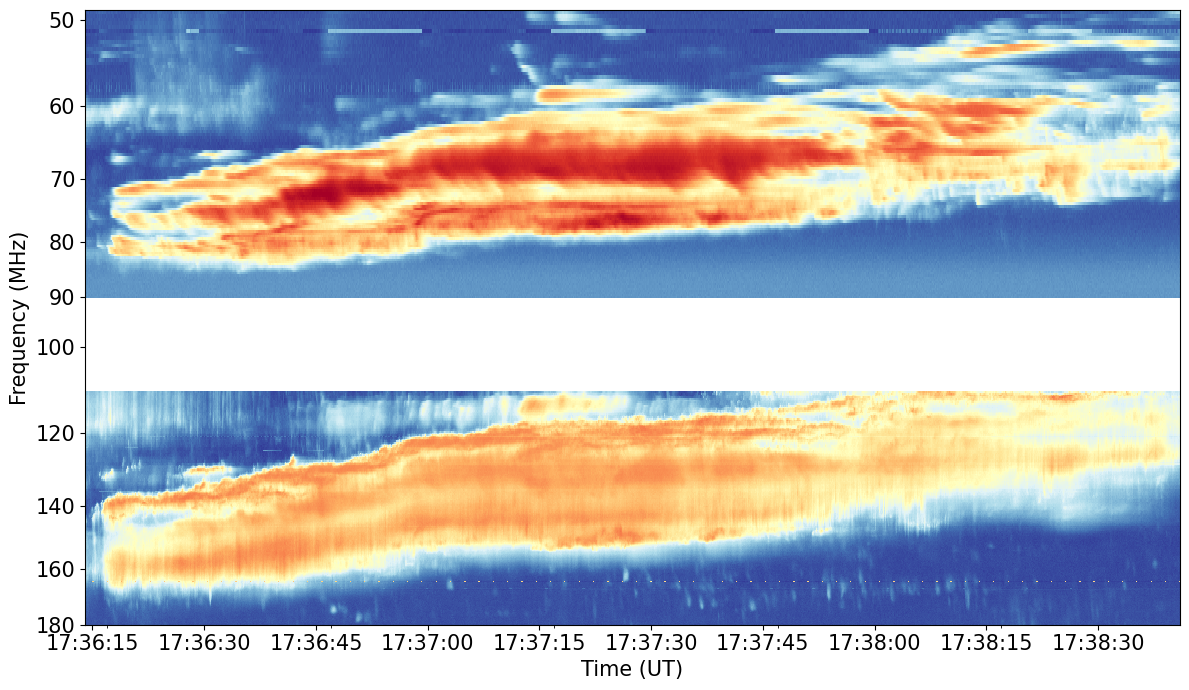

In [39]:
min_range = -0.5
max_range = 3

fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)
ax.pcolormesh(typeII_3_mode3.index, typeII_3_mode3.columns, typeII_3_mode3.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_3_mode5.index, typeII_3_mode5.columns, typeII_3_mode5.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_3_mode7.index, typeII_3_mode7.columns, typeII_3_mode7.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

# Define the custom ticks
# custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200]
custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 140, 160, 180]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks], fontsize = 15)
ax.xaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlabel('Time (UT)', fontsize = 15)
ax.set_ylabel('Frequency (MHz)', fontsize = 15)
ax.xaxis_date()

# ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=30))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.tick_params(axis='x', labelsize=15)
# ax.set_ylim(190, 45)
ax.set_ylim(180, 49)
fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import fsolve


def n_to_freq(ne):
    """
    Calculate plasma frequency [MHz] from electron density [cm-3].
    """
    fpe = 8.98e-3 * np.sqrt(ne)
    return fpe


def newkirk(r, fold=1):
    """
    Newkirk electron-density model.
    fold: is a multiplicative factor to change the density scaling.
    """
    model = fold * 4.2e4 * 10 ** (4.32 / r)
    return model


def height_to_freq(r):
    """
    Convert radial height (in Rsun) to plasma frequency (MHz)
    using the Newkirk density model.
    """
    ne = newkirk(r)
    fpe = n_to_freq(ne)
    return fpe



dflf = pd.read_csv('/home/mnedal/data/csv_files/SRB_heights/heights_newest_3LF.csv')
dfmf = pd.read_csv('/home/mnedal/data/csv_files/SRB_heights/heights_newest_3MF.csv')
dfuf = pd.read_csv('/home/mnedal/data/csv_files/SRB_heights/heights_newest_3UF.csv')

timef = dflf['Time'].values
freqslf = height_to_freq(dflf['1 Newkirk'].values)
freqsmf = height_to_freq(dfmf['1 Newkirk'].values)
freqsuf = height_to_freq(dfuf['1 Newkirk'].values)

dflh = pd.read_csv('/home/mnedal/data/csv_files/SRB_heights/heights_newest_3LH.csv')
dfmh = pd.read_csv('/home/mnedal/data/csv_files/SRB_heights/heights_newest_3MH.csv')
dfuh = pd.read_csv('/home/mnedal/data/csv_files/SRB_heights/heights_newest_3UH.csv')

timeh = dflh['Time'].values
freqslh = height_to_freq(dflh['1 Newkirk'].values)
freqsmh = height_to_freq(dfmh['1 Newkirk'].values)
freqsuh = height_to_freq(dfuh['1 Newkirk'].values)


min_range = -0.5
max_range = 3

fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)
ax.pcolormesh(typeII_3_mode3.index, typeII_3_mode3.columns, typeII_3_mode3.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_3_mode5.index, typeII_3_mode5.columns, typeII_3_mode5.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_3_mode7.index, typeII_3_mode7.columns, typeII_3_mode7.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

ax.scatter(timef, freqslf, c='k')
ax.scatter(timef, freqsmf, c='k')
ax.scatter(timef, freqsuf, c='k')

ax.scatter(timeh, freqslh)
ax.scatter(timeh, freqsmh)
ax.scatter(timeh, freqsuh)

custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 140, 160, 180]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks], fontsize = 15)
ax.xaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlabel('Time (UT)', fontsize = 15)
ax.set_ylabel('Frequency (MHz)', fontsize = 15)
ax.xaxis_date()
ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=30))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.tick_params(axis='x', labelsize=15)
ax.set_ylim(180, 49)
fig.tight_layout()
plt.show()

In [43]:
len(typeII_3_mode3.index), len(freqslf)

(112152, 30)

In [ ]:
min_range = -0.5
max_range = 0.7

fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)
ax.pcolormesh(typeII_4_mode3.index, typeII_4_mode3.columns, typeII_4_mode3.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_4_mode5.index, typeII_4_mode5.columns, typeII_4_mode5.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_4_mode7.index, typeII_4_mode7.columns, typeII_4_mode7.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

# Define the custom ticks
custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks], fontsize = 17)
# ax.xaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlabel('Time (UT)', fontsize = 17)
ax.set_ylabel('Frequency (MHz)', fontsize = 17)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
# Define minor ticks every 2 minutes
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

ax.tick_params(axis='x', labelsize=17)
ax.set_ylim(85, 25)
#plt.show()
plt.savefig(f"typeII_1717.png")

In [ ]:
min_range = -0.5
max_range = .9

fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)
ax.pcolormesh(typeII_5_mode3.index, typeII_5_mode3.columns, typeII_5_mode3.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_5_mode5.index, typeII_5_mode5.columns, typeII_5_mode5.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_5_mode7.index, typeII_5_mode7.columns, typeII_5_mode7.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

# Define the custom ticks
custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks], fontsize = 17)
# ax.xaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlabel('Time (UT)', fontsize = 17)
ax.set_ylabel('Frequency (MHz)', fontsize = 17)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.tick_params(axis='x', labelsize=17)
ax.set_ylim(90, 25)
#plt.show()
plt.savefig(f"typeII_1710.png")

In [ ]:
min_range = -0.5
max_range = 1.1

fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)
ax.pcolormesh(typeII_6_mode3.index, typeII_6_mode3.columns, typeII_6_mode3.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_6_mode5.index, typeII_6_mode5.columns, typeII_6_mode5.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_6_mode7.index, typeII_6_mode7.columns, typeII_6_mode7.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

# Define the custom ticks
custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks], fontsize=17)
# ax.xaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlabel('Time (UT)', fontsize = 17)
ax.set_ylabel('Frequency (MHz)', fontsize = 17)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.tick_params(axis='x', labelsize=17)
ax.set_ylim(80, 20)
#plt.show()
plt.savefig(f"typeII_1702.png")

In [ ]:
min_range = -0.5
max_range = 1.55

fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)
ax.pcolormesh(typeII_7_mode3.index, typeII_7_mode3.columns, typeII_7_mode3.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_7_mode5.index, typeII_7_mode5.columns, typeII_7_mode5.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(typeII_7_mode7.index, typeII_7_mode7.columns, typeII_7_mode7.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

# Define the custom ticks
custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 140, 160, 180, 200]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks], fontsize = 17)
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlabel('Time (UT)', fontsize = 17)
ax.set_ylabel('Frequency (MHz)', fontsize = 17)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.tick_params(axis='x', labelsize=17)
ax.set_ylim(190, 45)
#plt.show()
plt.savefig(f"typeII_1734.png")

In [ ]:
min_range = -0.5
max_range = 1.9

fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)
ax.pcolormesh(CME_2_mode3.index, CME_2_mode3.columns, CME_2_mode3.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(CME_2_mode5.index, CME_2_mode5.columns, CME_2_mode5.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(CME_2_mode7.index, CME_2_mode7.columns, CME_2_mode7.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

# Define the custom ticks
custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 140, 180, 220]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks], fontsize = 15)
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlabel('Time (UT)', fontsize = 15)
ax.set_ylabel('Frequency (MHz)', fontsize = 15)
ax.xaxis_date()

ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
# Define minor ticks every 2 minutes
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.tick_params(axis='x', labelsize=15)
ax.set_ylim(240, 20)
#plt.show()
plt.savefig(f"CME_2.png")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator

# Your existing data and configuration
min_range = -0.5
max_range = 1.9

fig = plt.figure(figsize=[12, 7])
ax = fig.add_subplot(111)
ax.pcolormesh(CME_2_mode3.index, CME_2_mode3.columns, CME_2_mode3.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(CME_2_mode5.index, CME_2_mode5.columns, CME_2_mode5.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.pcolormesh(CME_2_mode7.index, CME_2_mode7.columns, CME_2_mode7.values.T,
              vmin=min_range, vmax=max_range, cmap='RdYlBu_r')
ax.set_yscale('log')

# Define the custom y-ticks
custom_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 140, 180, 220]
ax.set_yticks(custom_ticks)
ax.set_yticklabels([str(tick) for tick in custom_ticks], fontsize=15)
ax.yaxis.set_minor_locator(AutoMinorLocator(n=5))

# Increase the number of x-ticks
# Define major ticks every 10 minutes
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
# Define minor ticks every 2 minutes
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

ax.set_xlabel('Time (UT)', fontsize=15)
ax.set_ylabel('Frequency (MHz)', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.set_ylim(240, 20)
#plt.savefig(f"CME_2.png")
plt.show()

In [ ]:
def newkirk_h(r):
     """
#     Newkirk electron-density model; harmonic emission.
#     e.g. `fold` is a multiplicative factor to change the density scaling.
#     """
     fold = 2.5
     model = fold*4.2e4*10**(4.32/r)
     return model

In [ ]:
E0 = 
me = 
qe = 

def freq_to_R(f_pe, ne_r):
    n = (f_pe**2)*E0*me/qe
     n
    return R

In [ ]:
# # Hz
freq = 40*1e6 # --> MHz
print(f'Assuming fundamental emission:\t{freq_to_R(f_pe=freq, ne_r=newkirk_h)[0]:.2f} Rs')
print(f'Assuming harmonic emission:\t{freq_to_R(f_pe=(freq/2), ne_r=newkirk_h)[0]:.2f} Rs')

# # calc the height from Newkirk model, in Rs 
rmodel = freq_to_R(f_pe=(freqs[i]/2)*1e6, ne_r=newkirk_h)[0]

# # calc the height on the plane of sky (POS), in Rs
rpos = np.sqrt(xshift**2 + yshift**2)

# ### +Z Solution

# # calc the distance from the POS, in Rs
zshift = np.sqrt(rmodel**2 - rpos**2)